In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from natsort import natsorted
import matplotlib.pyplot as plt
import h5py
from scipy import ndimage
#plt.style.use('./graph_preset.mplstyle')

In [18]:
def find_threshold_crossing_times(
    x,
    y,
    threshold,
    start=0,
    stop=None,
    direction="down",
):

    time = np.asarray(x, dtype=float)
    signal = np.asarray(y, dtype=float)

    if time.ndim != 1 or signal.ndim != 1:
        raise ValueError("x and y must be one-dimensional arrays")

    if len(time) != len(signal):
        raise ValueError("x and y must have the same length")

    n = len(signal)

    if stop is None:
        stop = n

    start = max(0, start)
    stop = min(stop, n)

    if stop - start < 2:
        empty = np.array([], dtype=float)
        return empty, empty, empty, empty

    # 隣接する2点
    t_left = time[start : stop - 1]
    t_right = time[start + 1 : stop]

    y_left = signal[start : stop - 1]
    y_right = signal[start + 1 : stop]

    # 交差区間の検出
    if direction == "down":
        mask = (y_left > threshold) & (y_right <= threshold)

    elif direction == "up":
        mask = (y_left < threshold) & (y_right >= threshold)

    elif direction == "both":
        mask = (
            ((y_left > threshold) & (y_right <= threshold))
            | ((y_left < threshold) & (y_right >= threshold))
        )

    else:
        raise ValueError("direction error")

    # NaNやinfを含む区間を除外
    mask &= (
        np.isfinite(t_left)
        & np.isfinite(t_right)
        & np.isfinite(y_left)
        & np.isfinite(y_right)
    )

    # 信号値が変化していない区間を除外
    mask &= y_right != y_left

    # 閾値通過時刻の線形補間
    crossing_times = (
        t_left[mask]
        + (threshold - y_left[mask])
        / (y_right[mask] - y_left[mask])
        * (t_right[mask] - t_left[mask])
    )

    periods = np.diff(crossing_times)

    freq = 1.0 / periods / 512.

    freq_time = (
        crossing_times[:-1] + crossing_times[1:]
    ) / 2.0

    return crossing_times, periods, freq_time, freq

In [19]:
run_dir = Path("./")
df_data = {}

read_path = run_dir / "260731175225.h5"
read_path = run_dir / "260731175921.h5"
read_path = run_dir / "260730124909.h5"

with h5py.File(read_path, "r") as f:

    ds = f["logs/log"]
    print(f"Loading: /logs/log | Shape: {ds.shape}")

    df = pd.DataFrame(ds[:])

    #df.columns = ["rel_time", "com", "vel", "I_u", "V_u", "I_v", "V_v", "I_w", "V_w", "Ptot_sum"]
    df.columns = ["rel_time", "com", "vel", "I_u", "V_u", "I_v", "V_v", "I_w", "V_w", "Ptot_sum", "J_u", "J_v", "J_w", "Jtot", "A"]
    #df.columns = ["rel_time", "com", "vel", "I_u", "V_u", "I_v", "V_v", "I_w", "V_w", "Ptot_sum", "J_u", "J_v", "J_w", "Jtot"]               
    #df = df.drop(columns=["com", "I_v", "V_v", "I_w", "V_w"], errors="ignore")

    df_data = {"logs/log": df}

Loading: /logs/log | Shape: (91696910, 15)


(4000.0, 4000.1)

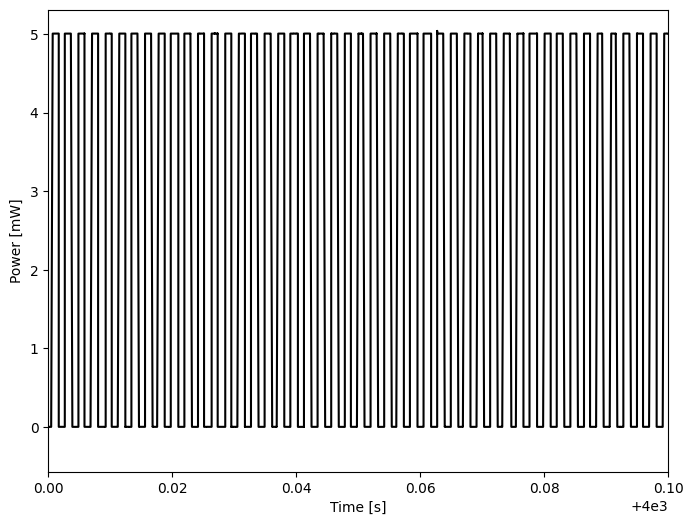

In [20]:
fig, ax = plt.subplots(figsize=(8, 6), dpi=100)
x = df_data["logs/log"]["rel_time"].iloc[::]
y = df_data["logs/log"]["A"].iloc[::]
ax.plot(x, y, label="a", color="k")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Power [mW]")

#ax.axhline(6, ls="--", c='red'),

#ax.set_ylim(-20, 40)
#ax.set_xlim(0, 50000)
ax.set_xlim(4000, 4000.1)

#ax.set_xlim(1371.1, 1371.4)

In [21]:
f_s = 10000

initial_index = int(1000 * f_s)
final_index = int(8000 * f_s)
x = df_data["logs/log"]["rel_time"].to_numpy()
y = df_data["logs/log"]["A"].to_numpy()


_, _, freq_t, freq = find_threshold_crossing_times(
    x=x,
    y=y,
    threshold=3,
    start=initial_index,
    stop=final_index,
    direction="up",
)

Text(0, 0.5, 'Freqeuency [Hz]')

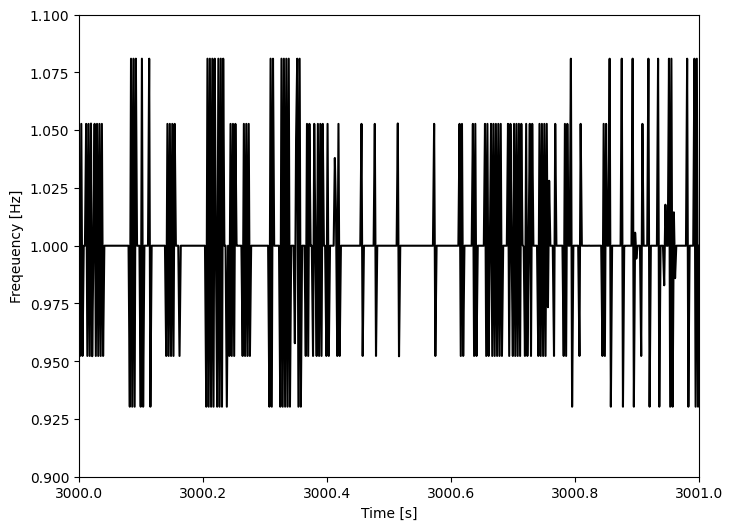

In [22]:
fig, ax = plt.subplots(figsize=(8, 6), dpi=100)
ax.plot(freq_t, freq, label="A", color="k")

ax.set_ylim(0.9,1.1)
ax.set_xlim(3000,3001)
ax.set_xlabel("Time [s]")
ax.set_ylabel("Freqeuency [Hz]")